# Introduction:
In this notebook is the sentiment analysis of tweets from various twitter handles.
There are 3 major categories which represent the sentiments of the people:
- 0 represents a netural tweet
- -1 represents a negative tweet
- 1 represents a positive tweet

## Objective: 
To build a robust NLP classifier that can accurately distinguish between the political and social discourse and provide insights while training the model with TF-IDF vectorization and supervised learning.

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from collections import Counter
import nltk
from nltk.corpus import stopwords
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
import re


data=pd.read_csv("Twitter_Data.csv")


In [2]:
data.head()

,clean_text,category
0,when modi promised “minimum government maximum...,-1.0
1,talk all the nonsense and continue all the dra...,0.0
2,what did just say vote for modi welcome bjp t...,1.0
3,asking his supporters prefix chowkidar their n...,1.0
4,answer who among these the most powerful world...,1.0


In [3]:
data.dtypes
#The category column is of the float datatype but machine learning models prefer integer datatype. Let us convert the data type of the column "Category"

clean_text     object
category      float64
dtype: object

In [4]:
# Before chanign the data type, we will check for any null values 
data.isnull().sum()

clean_text    4
category      7
dtype: int64

In [5]:
#Since the number of null values is less, we just drop the values. 
#The reason to drop the values is that the dataset consists of 162980 unique values. So dropping these null values would not effect the analysis 
data.dropna(inplace=True)

In [6]:
print(f"Missing values: {data.isnull().sum().sum()}")
print(f"Duplicate rows: {data.duplicated().sum()}")

Missing values: 0
Duplicate rows: 0


In [7]:
# Now lets change the datatype of the column "category" from float to integer
data['category']=data['category'].astype(int)

In [8]:
data.dtypes

clean_text    object
category       int64
dtype: object

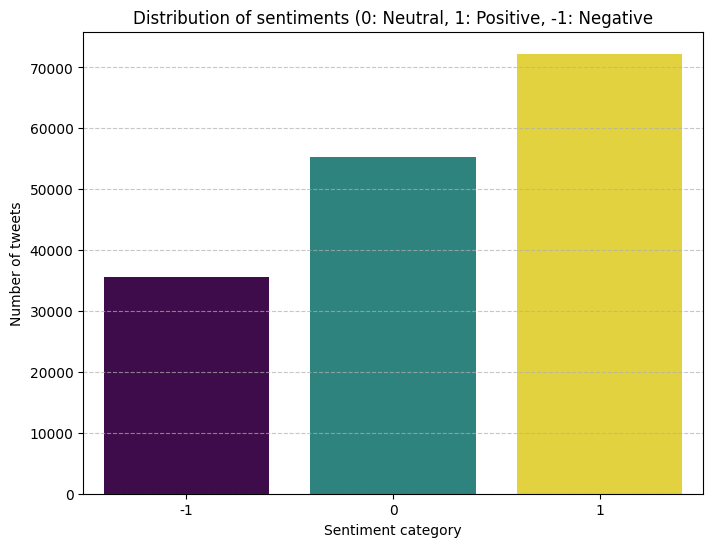

In [9]:
# Let us model the number of tweets per category
plt.figure(figsize=(8,6))
sns.countplot(x='category',data=data,palette='viridis',hue='category',legend=False)
plt.title("Distribution of sentiments (0: Neutral, 1: Positive, -1: Negative")
plt.xlabel("Sentiment category")
plt.ylabel("Number of tweets")
plt.grid(axis='y',linestyle='--',alpha=0.7)
plt.show()

## Observations:

An initial analysis of the dataset reveals a notable imbalance between the sentiment classes. Key findings include:

- Positive Sentiment (1): Dominates the dataset with approximately 72,000 entries, nearly doubling the volume of negative sentiment.

- Neutral Sentiment (0): Occupies a significant middle ground with roughly 55,000 entries.

- Negative Sentiment (-1): Represents the smallest class at approximately 35,000 entries.

The prevalence of positive tweets suggests that the final model may develop a slight bias toward positive predictions. We will need to monitor the Precision-Recall trade-off during the evaluation phase to ensure the model remains sensitive to the less-represented negative class.

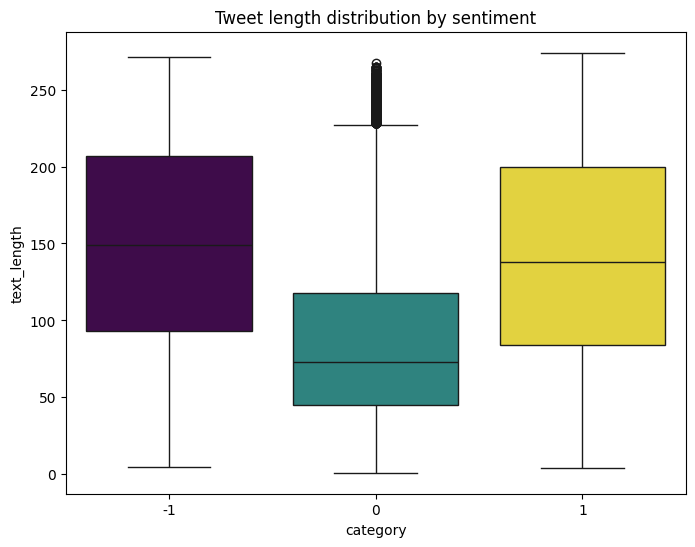

In [10]:
# Lets analyze the length of the texts
data['text_length']=data['clean_text'].astype(str).apply(len)
plt.figure(figsize=(8,6))
sns.boxplot(x='category',y='text_length',data=data,palette='viridis',hue='category',legend=False)
plt.title("Tweet length distribution by sentiment")
plt.show()


# Observation:
A comparative analysis of tweet lengths across the three sentiment categories reveals several key behavioral patterns in the dataset:

- Emotional Intensity vs. Length: Both Negative (-1) and Positive (1) sentiments exhibit higher median lengths and wider interquartile ranges (IQR) compared to neutral tweets. This suggests that users expressing a clear opinion (whether favorable or critical) tend to use more descriptive language and a higher word count to convey their message.

- Neutral Conciseness: The Neutral (0) category shows a significantly lower median character count and a "tighter" distribution. Neutral tweets in this dataset are often concise, likely representing factual statements, news headlines, or brief objective observations.

- Outlier Presence (Neutral Class): Interestingly, the neutral category contains a dense cluster of high-end outliers. While most neutral tweets are short, there is a specific subset of long-form neutral content that exceeds the typical length of even the most "extreme" emotional tweets.

- Consistency in Extremes: The maximum lengths for all three categories are capped around the same level (likely due to Twitter's character limit or specific dataset filtering), but the "bulk" of the sentiment-heavy data lives in the 100–200 character range.

Conclusion: Since length varies significantly by class, text_length could actually be a useful feature for our model. However, to ensure the model learns meaning rather than just length, we will proceed with TF-IDF Vectorization to focus on word importance.

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Rajeev\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
C:\Users\Rajeev\AppData\Local\Temp\ipykernel_14988\3834831142.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=[val[1] for val in top_pos], y=[val[0] for val in top_pos], ax=ax1, palette='Greens_r')
C:\Users\Rajeev\AppData\Local\Temp\ipykernel_14988\3834831142.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=[val[1] for val in top_neg], y=[val[0] for val in top_neg], ax=ax2, palette='Reds_r')


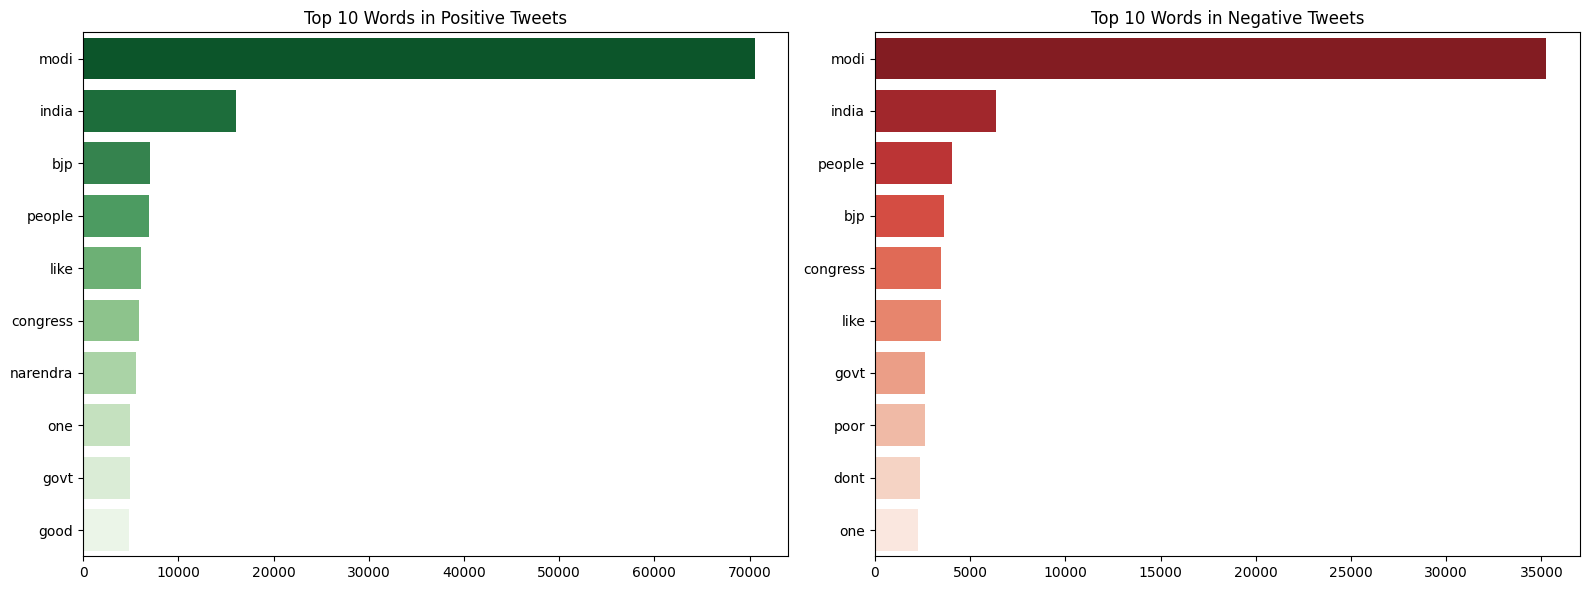

In [11]:
# Now we will identify the top 10 most repeated words
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

def final_clean(text):
    text = str(text).lower()
    text = re.sub(r'[^a-z\s]', '', text)
    words = text.split()
    important_words = [w for w in words if w not in stop_words]
    
    return " ".join(important_words)
data['clean_text'] = data['clean_text'].apply(final_clean)
def get_top_n_words(sentiment_label, n=10):
    all_text = ' '.join(data[data['category'] == sentiment_label]['clean_text'].astype(str))
    words = all_text.split() 
    return Counter(words).most_common(n)


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

top_pos=get_top_n_words(1)
top_neg=get_top_n_words(-1)

# Plotting Positive tweets
sns.barplot(x=[val[1] for val in top_pos], y=[val[0] for val in top_pos], ax=ax1, palette='Greens_r')
ax1.set_title('Top 10 Words in Positive Tweets')

# Plotting Negative tweets
sns.barplot(x=[val[1] for val in top_neg], y=[val[0] for val in top_neg], ax=ax2, palette='Reds_r')
ax2.set_title('Top 10 Words in Negative Tweets')

plt.tight_layout()
plt.show()

By filtering out non-descriptive stopwords, we can now observe the specific terms that characterize each sentiment category:

Shared Political Context: The presence of "modi", "india", "bjp", and "congress" across both charts confirms that the dataset is centered on Indian political discourse. Since these terms are frequent in both Positive and Negative classes, they serve as the contextual anchor, while surrounding words will provide the actual sentiment signal.

Positive Sentiment Indicators:

"Good" and "one" appear as top drivers, indicating supportive or affirmative feedback.

The term "narendra" surfaces here but not in the top 10 negative words, suggesting that more formal or respectful naming conventions correlate with positive sentiment in this dataset.

Negative Sentiment Indicators:

"Poor" and "dont" (don't) emerge as clear negative markers, likely linked to criticisms of policy or governance.

The word "people" is more prominent in the negative list, which often points to grievances regarding public impact or societal issues.

Data Readiness: With "filler" words removed, the vocabulary is now specialized and feature-rich. We can proceed to TF-IDF Vectorization, confident that the model will focus on these meaningful keywords rather than grammatical structure.

In [12]:
X = data['clean_text']
y = data['category']

#Splitting the data 70-30
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

#Initializing TF-IDF Vectorizer

tfidf = TfidfVectorizer(max_features=5000)

#Transforming the text into numbers
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

#Training the Logistic Regression Model
model = LogisticRegression(max_iter=1000)
model.fit(X_train_tfidf, y_train)

#Predicting on the test set
y_pred = model.predict(X_test_tfidf)

print("Model Accuracy and Classification Report:")
print(classification_report(y_test, y_pred))

Model Accuracy and Classification Report:
              precision    recall  f1-score   support

          -1       0.88      0.77      0.82     10691
           0       0.86      0.97      0.91     16644
           1       0.92      0.89      0.90     21556

    accuracy                           0.89     48891
   macro avg       0.89      0.87      0.88     48891
weighted avg       0.89      0.89      0.89     48891



Insights: Model Performance Evaluation
Overall Accuracy (89%): The model is highly reliable. It correctly identifies the sentiment of nearly 9 out of 10 tweets it has never seen before.

Neutral (0): The model performs best on neutral tweets with a 0.97 recall. This means it almost never misses a neutral statement. This is common in political datasets where factual news headlines have very distinct patterns.

The Positive (1) vs. Negative (-1):

Positive tweets have a very high Precision (0.92), meaning when the model says a tweet is positive, it's almost always right.

Negative tweets have the lowest Recall (0.77). This is our "Insight": the model occasionally struggles to catch every negative tweet, likely because sarcasm or subtle criticism is harder for a basic model to detect than clear praise.

Reliability: The F1-scores (0.82 to 0.91) are consistent across the board, proving the model isn't just "guessing" the majority class; it has genuinely learned the features of all three sentiments.

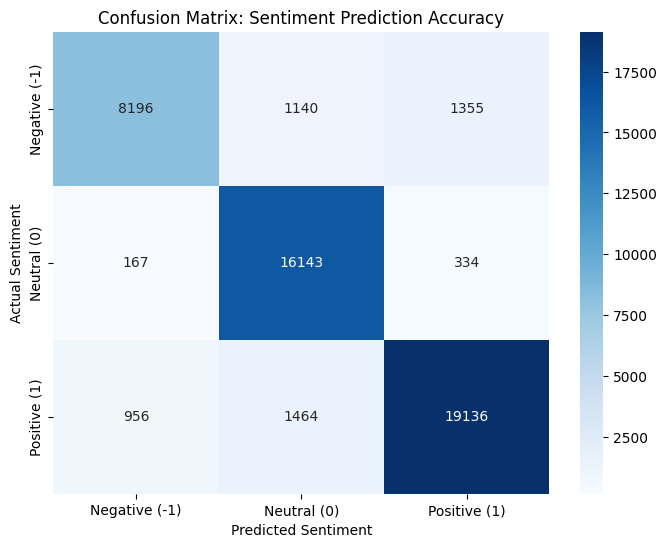

In [13]:
#Lets plot the confusion matrix to visualize the result
cm=confusion_matrix(y_test,y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Negative (-1)', 'Neutral (0)', 'Positive (1)'],
            yticklabels=['Negative (-1)', 'Neutral (0)', 'Positive (1)'])

plt.xlabel('Predicted Sentiment')
plt.ylabel('Actual Sentiment')
plt.title('Confusion Matrix: Sentiment Prediction Accuracy')
plt.show()

## Confusion matrix insight:


The Confusion Matrix provides a granular look at where the model succeeds and where it encounters difficulty:

Strong Diagonal Performance: The dark blue boxes running from the top-left to bottom-right represent the True Positives (where the model’s prediction matched the actual label). The high numbers here (16,143 for Neutral and 19,136 for Positive) demonstrate the model's overall robustness.

Neutral Clarity: The model is exceptionally good at identifying Neutral (0) tweets, with very few "leakages" into the Positive or Negative categories.

The Sentiment Blur: * 1,355 Negative tweets were misclassified as Positive.

956 Positive tweets were misclassified as Negative.
This "blur" is standard in social media NLP. It often occurs due to sarcasm or complex language where a user might use "positive" words to describe a "negative" situation (e.g., "Great job on the traffic today, city council!").

Efficiency: Despite the class imbalance we noted during EDA (having fewer negative tweets), the model still correctly identified 8,196 negative tweets, proving that the TF-IDF vectorization effectively captured the unique vocabulary of the minority class.

# Conclusion: 

Data Composition & Quality
The Landscape: Our dataset of over 160,000 tweets is primarily Positive (~45%) and Neutral (~35%), with Negative (~20%) sentiment being the minority.

Data Integrity: Through initial EDA, we confirmed a clean dataset with zero missing values and zero duplicates, ensuring the model was trained on high-quality, unique human discourse.

Behavioral Insights (The "How" of Tweeting)
Intensity vs. Length: Our boxplot analysis revealed that people use significantly more characters (150–250) when expressing strong emotions (Positive or Negative).

Neutral Conciseness: Neutral tweets are typically shorter and more "factual," often falling under 100 characters.

The Outlier Decision: We identified several "long-form" outliers but chose to retain them to capture the full depth of detailed public feedback, relying on TF-IDF to handle the varied lengths.

Thematic Analysis (The "What" of Tweeting)
The Political Anchor: Post-stopword removal, we found that "Modi," "India," "BJP," and "Govt" were the core subjects across all sentiments.

Sentiment Signifiers: We successfully isolated "True Sentiment" words (e.g., "Good," "Narendra" for Positive vs. "Poor," "Dont" for Negative), proving that our cleaning process successfully separated the subject from the emotion.

Model Effectiveness
High Reliability: The Logistic Regression model achieved a Weighted F1-Score of 0.89, indicating that the model is highly capable of distinguishing between political praise and criticism.

The Confusion Matrix Verdict: The model is nearly "perfect" at identifying Neutral statements. The small amount of "confusion" (approx. 5–8%) between Positive and Negative tweets is a natural result of linguistic complexities like sarcasm, which is an expected threshold in modern NLP.

In [14]:
pd.to_csv('twitter_data_cleaned.csv')

AttributeError: module 'pandas' has no attribute 'to_csv'